# Closing the carbon budget in B-SOSE
*Contributors*: [Iris Liang](https://github.com/xliang576)

This is a full example of how to build a dissolved organic carbon budget in [B-SOSE](https://odyn-standrews.github.io/wiki/bsose/), and to do quick checks whether it is "closed". See more information on budget at [this wiki page](https://odyn-standrews.github.io/wiki/closing-budgets-in-MITgcm/) and references within.

Being a state estimate model, BSOSE has the capacity to fully close budgets - unless tricky things happen when the model diagnostics are generated or stored. Here are [some BSOSE biogeochemical budget examples](https://sose.ucsd.edu/budgets/). Here is a list of [available diagnostics](https://sose.ucsd.edu/SO6/ITER155/available_diagnostics.log) in B-SOSE.

# Before start

Some simulation-specific settings requires attention. Specificlly, the nonlinear or linear free surface, and (if nonlinear free surface) the $r$ or $r^*$ coordinate applied in model run require slightly different handling in some parts. 

Model runs with linear free surface omit the time-varying sea surface height anomaly $\eta$ (due to freshwater fluxes and other unbalanced volume transport) when advecting tracers. Runs with nonlinear free surface accounts for $\eta$ in the tracer transport, by adjusting the concentration of tracers corresponding to the changing cell volume from $\eta$. When making the adjustment, $r$ coordinates compromise all the adjustments into the surface layer while $r^*$ coordinates spread the adjustment through out the whole column.

See more information on nonlinear free surface [here](https://mitgcm.readthedocs.io/en/latest/algorithm/nonlinear-freesurf.html), on coordinates [here](https://mitgcm.readthedocs.io/en/latest/overview/overview.html#continuous-equations-in-r-coordinates).

## DIC tracer equation
DIC conservation equation is 

```math
\frac{\partial DIC}{\partial t} = - \vec{u} \cdot \nabla DIC + \gamma \nabla^2 DIC + \mathcal{F_a} + Bio
```
where $DIC$ is the concentration of DIC, $\vec{u}$ is the velocity field, $\gamma \nabla^2 DIC$ represents the diffusive process in a simplified form, $\mathcal{F_a}$ denotes the surface flux, and $Bio$ denotes the effect of biological processes.

Written in Budget term is

```math
TEND = ADV + DIFF + SURF + BIO
```

The corresponding process and diagnostics for right hand side are given in the following table.

|   Term	|   Process	|   Diagnostics	|  
|---	|---	|---	|  
|   ADV	|   Advective transport	|   `ADVxTr01`,`ADVyTr01`,`ADVrTr01`|  
|   DIFF	|   Diffusive transport	|   `DFxETr01`,`DFyETr01`,`DFrITr01`	|  
|   SURF	|   Surface sea-air carbon flux	|   `BLGCFLX`	|   
|   BIO	|   Biological source and sinks	|   `BLGBIOC`	|   



## A note on the timesteps of diagnostics
The "snapshots" diagnostics are snapshots at the end of 5-day/month, while other diagnostics are time-averaged over the period, storing under the timestep at the end of the 5-day/month. For example, for time '2015-01-03' to '2015-01-08', two 5-day snapshots are available, while the average of the 5-day are stored under '2015-01-08'. 

Make sure to have one more timestep at the beginning in "snapshots" to match the time correctly with averaged diagnostics.

# Calculate terms in carbon budget

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from xgcm import Grid
import warnings
warnings.filterwarnings('ignore')

Defining pathways of reading in data and output directory. The `datasets/bSOSE` directory is accessible to all members in the group workspace. The data are downloaded from [sose server](https://sose.ucsd.edu/SO6/ITER156/).

In [ ]:
year = '2014'
PATH = "/gws/nopw/j04/co2clim/datasets/bSOSE/ITER156/"
savedir = '/gws/nopw/j04/co2clim/xtiliang/Budget/'

## TEND

$`TEND`$ is the time difference of concentration, namely
```math 
\frac{DIC(t_{n+1}) - DIC(t_n)}{\Delta t} 
```

Adjustment of nonlinear free surface, $r^*$ coordinate:
```math
\frac{DIC(t_{n+1})*(1+h(t_{n+1}) /H)-DIC(t_n)*(1+\eta(t_{n}) /H)}{\Delta t} 
```
where $`\eta`$ is sea surface height anomaly (diagnostics`ETAN`), $`H`$ is ocean depth. 

For nonlinear free surface, $r$ coordinate, this adjustment is not needed here, but some corrections for the surface vertical advective flux (`ADVrTr01`) might be needed.



In [ ]:
# Calculate tendency
C = xr.open_dataset(PATH+f"{year}/DIC_bsoseI156_{year}_5daySnaps.nc")  # DIC concentration 
E = xr.open_dataset(PATH+f"{year}/SSH_bsoseI156_{year}_5daySnaps.nc")  # Sea surface height anomaly

TEND = (C['TRAC01'] * (1+E['ETAN']/E['Depth']) ).diff(dim = 'time') / 432000  # 432000 is seconds in 5 days
TEND = TEND.rename('TEND')

# TEND.to_netcdf(savedir+f'bsose_I156_{year}_5day_tendency-DIC.nc')


## ADV

The advective diagnostics `ADVxTr01`, `ADVyTr01`, `ADVrTr01` are advective fluxes on x,y,z direction. For example, `ADVxTr01` = u * DIC * hFac * dyG * drF. (The unit in description "molC/m.m^3/s" is wrong. It is "molC/s".) To get the divergence we need only difference and diveded by the cell volume. 

In [ ]:
# Build grid to use the grid.diff() function, which do difference accounting for the grid geometry.
A = xr.open_mfdataset(PATH+f"{year}/ADV*DIC_bsoseI156_{year}_5day.nc",chunks = {'time':1})

A['drW'] = A.hFacW * A.drF # vertical cell size at u point
A['drS'] = A.hFacS * A.drF # vertical cell size at v point
A['drC'] = C.hFacC * A.drF # vertical cell size at center
A['CV']= A.rA * A.drC # Cell volume 
A['rAW'] = A.dyG * A.drW # cell side areas at u location
A = A.set_coords( ("drW","drS","drC","CV","rAW") )

metrics = {
    ('X',): ['dxC', 'dxG'], # X distances
    ('Y',): ['dyC', 'dyG'], # Y distances
    ('Z',): ['drF','drW', 'drS', 'drC'], # Z distances
    ('X', 'Y'): ['rA', 'rAs', 'rAw'] # Areas
}

grid = Grid(A,  periodic=['X'],  metrics = metrics)


In [ ]:
# Calculate advection
ADV = - (grid.diff(A['ADVxTr01'],'X') 
         + grid.diff(A['ADVyTr01'],'Y',boundary = 'extend') 
         - grid.diff(A['ADVrTr01'],'Z',boundary = 'fill', fill_value = 0) ) / A.CV  # careful the negative sign in Z 

ADV = ADV.rename('ADV')
# ADV.to_netcdf(savedir+f'bsose_I156_{year}_5day_advection-DIC.nc')


## DIFF 
Same as ADV.

In [ ]:
# Calculate diffusion
D = xr.open_mfdataset(PATH+f"{year}/DF*DIC_bsoseI156_{year}_5day.nc",chunks = {'time':1})

DIFF = - (  grid.diff(D['DFxETr01'],'X')
          + grid.diff(D['DFyETr01'],'Y',boundary = 'extend')
          - grid.diff(D['DFrITr01'],'Z',boundary = 'fill', fill_value = 0) ) / A.CV  # negative sign in Z
DIFF = DIFF.rename('DIFF')

# DIFF.to_netcdf(savedir+f'bsose_I156_{year}_5day_diffusion-DIC.nc')

## SURF

Surface air-sea CO2 flux.

In [ ]:
# Calculate tendency due to surface CO2 flux
S = xr.open_dataset(PATH+f"{year}/surfCO2flx_bsoseI156_{year}_5day.nc")

SURF = S['BLGCFLX'] / ( A.hFacC[0,:,:]* A.drF[0] ) 
SURF = SURF.rename('SURF')

# SURF.to_netcdf(savedir+f'bsose_I156_{year}_5day_surfaceflux-DIC.nc')


## BIO
Biological processes.

In [ ]:
# Calculate Biology
B = xr.open_dataset(PATH+f"{year}/BLGBIOC_bsoseI156_{year}_5day.nc")
BIO = B['BLGBIOC'].rename('BIO')

# BIO.to_netcdf(savedir+f'bsose_I156_{year}_5day_bio-DIC.nc')

In [ ]:
# # Calculate residual
maskZ = xr.DataArray(np.zeros(len(A['Z'])),dims=['Z'],coords={'Z':A['Z']})
maskZ[0] = 1  


RES = TEND - ADV - DIFF - SURF * maskZ - BIO
RES.rename('RES')

# RES.to_netcdf(savedir+f'bsose_I156_{year}_5day_residual-DIC.nc')

# Check the budget

We have derived the full budget. We can plot depth profiles at random locations to see the bahaviour of each term, and check the residual is sufficiently small.

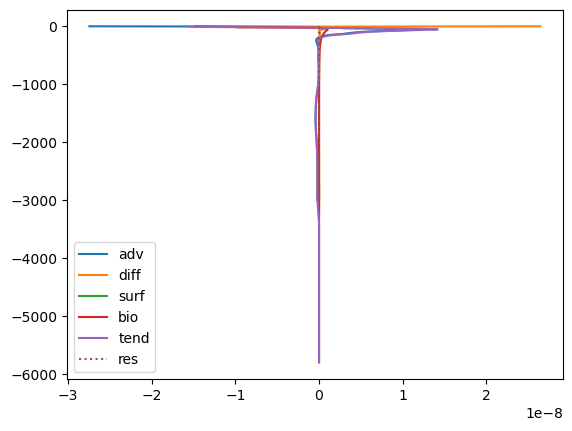

In [14]:
iy = 330
ix = 900
fig, ax = plt.subplots()
ax.plot( ADV.isel(time=0,XC=ix, YC=iy),A.Z,label = 'adv')
ax.plot(DIFF.isel(time=0,XC=ix, YC=iy),A.Z,label = 'diff')
ax.plot(SURF[0,:,iy,ix],A.Z[0],label = 'surf')
ax.plot(BIO [0,:,iy,ix],A.Z,label = 'bio')
ax.plot(TEND[0,:,iy,ix],A.Z,label = 'tend')
ax.plot(RES [0,:,iy,ix],A.Z,label = 'res',linestyle = ':')
ax.legend()
plt.close()
fig

Zoom in to upper ocean

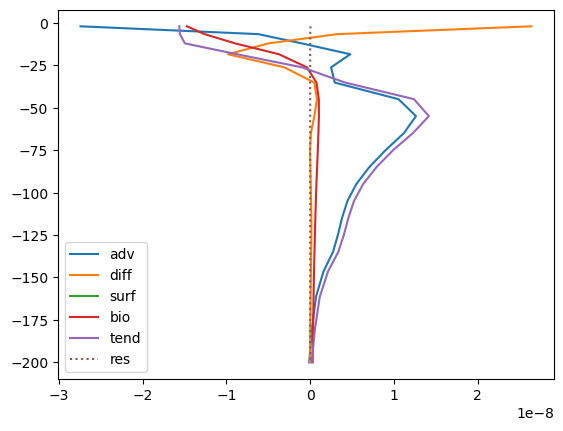

In [9]:
iy = 330
ix = 900
fig, ax = plt.subplots()
ax.plot( ADV.isel(time=0,XC=ix, YC=iy)[:20],A.Z[:20],label = 'adv')
ax.plot(DIFF.isel(time=0,XC=ix, YC=iy)[:20],A.Z[:20],label = 'diff')
ax.plot(SURF[0,:20,iy,ix],A.Z[0],label = 'surf')
ax.plot(BIO [0,:20,iy,ix],A.Z[:20],label = 'bio')
ax.plot(TEND[0,:20,iy,ix],A.Z[:20],label = 'tend')
ax.plot(RES [0,:20,iy,ix],A.Z[:20],label = 'res',linestyle = ':')
ax.legend()
plt.close()
fig

Advection contribute to tendency the most, biology decays with depth around surface - make sense. Check the residual closer.

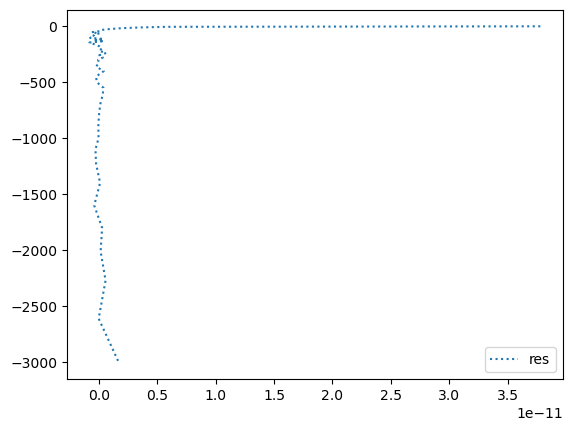

In [ ]:
fig, ax = plt.subplots()
ax.plot(RES [0,:,iy,ix],RES.Z[:],label = 'res',linestyle = ':')
ax.legend()
plt.close()
fig

Residual is a few magnitude smaller than processes, happy.